<a href="https://colab.research.google.com/github/Arham2702/jbhifi-price-drop-ml/blob/main/notebooks/ADAA_A2_price_drop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting JB Hi-Fi price drops: when, and by how much

**ADAA Assignment 2, Option 2 (practical ML system).**

**Task.** For a product that is buyable at JB Hi-Fi on decision day *t*, predict:
1. **When** its price will first drop by at least 5%: within 1-7 days, 8-14 days, 15-28 days, or not within 28 days (4-class probability vector).
2. **How deep** that first drop will be (percent of today's price).
3. A **BUY NOW / WAIT** recommendation derived from (1) and (2).

**Data.** Daily-ish scrapes (every 2-3 days) of the full JB Hi-Fi online catalogue, May to September 2026, collected by my own scraper into Supabase,
plus The Good Guys prices for the same model numbers. A frozen snapshot is downloaded below, so this notebook is self-contained.

**Sections.** 1 Setup, 2 Data loading and cleaning, 3 Labels, 4 Features, 5 Dummy interface, 6 Baselines and LightGBM,
7 Evaluation on unseen products, 8 Time-split check, 9 Buy-or-wait savings, 10 Top-10 demo, 11 Competitor ablation.

## 1. Setup

In [1]:
import importlib.util
import subprocess
import sys

for pkg in ["lightgbm", "pyarrow"]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

import json
import urllib.request
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import GroupKFold, GroupShuffleSplit

SEED = 42
np.random.seed(SEED)
pd.set_option("display.width", 160)

DROP_THRESHOLD = 0.05          # a "drop" = price at least 5% below today's price
HORIZON = 28                   # look-ahead window in days
BUCKET_NAMES = ["1-7 days", "8-14 days", "15-28 days", "no drop in 28 days"]
NO_DROP = 3                    # index of the "no drop" class
DECISION_START, DECISION_END = pd.Timestamp("2026-06-01"), pd.Timestamp("2026-08-31")

DATA_BASE_URL = "https://raw.githubusercontent.com/Arham2702/jbhifi-price-drop-ml/main/data"
DATA_DIR = Path("data") if Path("data").exists() else (Path("../data") if Path("../data").exists() else Path("data"))
FIG_DIR = Path("../report/figures") if Path("../report").exists() else Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
RESULTS = {}


def savefig(name):
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{name}.png", dpi=130, bbox_inches="tight")
    plt.show()

## 2. Data loading and cleaning

Four Parquet files exported (read-only) from my Supabase database by `scripts/export_supabase.py`:

| file | one row = | key columns |
|---|---|---|
| `jb_prices` | one SKU on one scrape date | `sku, date, price, on_promotion, buyable` |
| `jb_products` | one SKU | `title, product_type, vendor, model_number` |
| `jb_catalog_latest` | one product listed on the JB site on 28 Sep 2026 | `sku, price, jb_listing_cta` |
| `tgg_prices` | one model number on one The Good Guys scrape date | `model_number, date, tgg_price` |

The export already restricted JB rows to 10 appliance categories, price >= $50, from 1 May 2026, and SKUs that were buyable on at least 20 scrape days.
This is the **full** filtered catalogue (about 9 MB in total), so the notebook downloads it in seconds on Colab.

In [2]:
def load(name):
    path = DATA_DIR / f"{name}.parquet"
    if not path.exists():
        DATA_DIR.mkdir(parents=True, exist_ok=True)
        urllib.request.urlretrieve(f"{DATA_BASE_URL}/{name}.parquet", path)
    return pd.read_parquet(path)


prices = load("jb_prices")
products = load("jb_products")
catalog = load("jb_catalog_latest")
tgg = load("tgg_prices")
prices["date"] = pd.to_datetime(prices["date"])
tgg["date"] = pd.to_datetime(tgg["date"])
print(f"jb_prices: {len(prices):,} rows, {prices.sku.nunique():,} SKUs, {prices.date.min().date()} to {prices.date.max().date()}")
print(f"jb_products: {len(products):,} | catalogue now: {len(catalog):,} | TGG rows: {len(tgg):,}")

jb_prices: 877,585 rows, 15,322 SKUs, 2026-05-01 to 2026-09-28
jb_products: 15,322 | catalogue now: 40,952 | TGG rows: 398,712


**Cleaning.** Some scrape days only captured part of the catalogue (the scraper was interrupted).
A missing row on those days would look like a product disappearing, so days with fewer than 50% of the
typical row count (7-scrape rolling median) are removed entirely.

In [3]:
rows_per_day = prices.groupby("date").size()
typical = rows_per_day.rolling(7, center=True, min_periods=1).median()
partial_days = rows_per_day[rows_per_day < 0.5 * typical].index
prices = prices[~prices.date.isin(partial_days)]
print("removed partial scrape days:", [d.strftime("%d %b") for d in partial_days])
scrape_dates = pd.DatetimeIndex(sorted(prices.date.unique()))
print(f"{len(scrape_dates)} scrape dates kept")

removed partial scrape days: ['03 May', '05 May', '15 Jul', '09 Aug', '17 Aug', '19 Aug']
62 scrape dates kept


**Daily grid.** Each series is placed on a daily calendar (dates x SKUs). Days without a scrape are NaN.
`buy_price` drops prices on days the listing was not buyable (you cannot benefit from a price you cannot buy).
The scraper only recorded listing status from June; May rows have unknown status and are kept as buyable
(they only feed the price-history features, since the first decision date is in June).
`price_ff` carries the last seen price forward and is used for features only.

In [4]:
dates = pd.date_range(prices.date.min(), prices.date.max(), freq="D")
skus = np.array(sorted(prices.sku.unique()))


def wide(col):
    return (prices.pivot(index="date", columns="sku", values=col)
            .reindex(index=dates, columns=skus).astype("float32"))


obs_price = wide("price")
buyable = wide("buyable")
promo = wide("on_promotion")
buy_price = obs_price.where(buyable != 0)
price_ff = obs_price.ffill()
T, N = obs_price.shape
date_pos = {d: i for i, d in enumerate(dates)}
sku_pos = {s: j for j, s in enumerate(skus)}
print(f"grid: {T} days x {N:,} SKUs")

grid: 151 days x 15,322 SKUs


## 3. Labels: when does the first >= 5% drop happen, and how deep is it?

For decision day *t* with buyable price $p_t$, look at the buyable prices on days $t+1 \dots t+28$.
The first day $t+d$ with $p_{t+d} \le 0.95\,p_t$ is the drop day, **provided the next scrape after it is also at least 5% lower**
(a persistence rule that filters out one-scrape "blips" caused by scraper glitches).

* `bucket` = 0 if $d \le 7$, 1 if $8 \le d \le 14$, 2 if $15 \le d \le 28$, 3 if no drop
* `depth` = $1 - p_{t+d}/p_t$ (only defined when a drop happens)
* `end_price` = last buyable price on or before $t+28$ (what a shopper who waited the full 28 days would pay)

Only decision days up to **31 August** are used, because their full 28-day future is observed by 28 September.
Later days would have unknown (right-censored) outcomes.

In [5]:
P = buy_price.to_numpy()
next_obs = pd.DataFrame(P).shift(-1).bfill().to_numpy()   # next buyable price strictly after each day
first_day = np.full((T, N), np.nan, dtype="float32")
drop_price = np.full((T, N), np.nan, dtype="float32")
threshold = P * (1 - DROP_THRESHOLD)

with np.errstate(invalid="ignore"):
    for d in range(1, HORIZON + 1):
        fut = np.full((T, N), np.nan, dtype="float32")
        fut[:-d] = P[d:]
        fut_next = np.full((T, N), np.nan, dtype="float32")
        fut_next[:-d] = next_obs[d:]
        persists = (fut_next <= threshold) | np.isnan(fut_next)
        hit = (fut <= threshold) & persists & np.isnan(first_day)
        first_day[hit] = d
        drop_price[hit] = fut[hit]

end_price = np.full((T, N), np.nan, dtype="float32")
end_price[:-HORIZON] = buy_price.ffill().to_numpy()[HORIZON:]

bucket_grid = np.select([first_day <= 7, first_day <= 14, first_day <= 28], [0, 1, 2], default=NO_DROP)
depth_grid = 1 - drop_price / P

**Decision dates.** One decision date per week (the first kept scrape of each week, 1 Jun to 31 Aug),
for every SKU that was buyable that day. Weekly sampling avoids near-duplicate samples from consecutive scrapes.

In [6]:
in_window = scrape_dates[(scrape_dates >= DECISION_START) & (scrape_dates <= DECISION_END)]
decision_dates = pd.Series(in_window).groupby(in_window.to_period("W")).min().tolist()
dec_idx = np.array([date_pos[d] for d in decision_dates])
ti, sj = np.nonzero(~np.isnan(P[dec_idx]))
ti = dec_idx[ti]

samples = pd.DataFrame({
    "t": ti, "j": sj,
    "date": dates[ti], "sku": skus[sj],
    "price": P[ti, sj],
    "bucket": bucket_grid[ti, sj],
    "drop_day": first_day[ti, sj],
    "depth": depth_grid[ti, sj],
    "drop_price": drop_price[ti, sj],
    "end_price": end_price[ti, sj],
})
samples["end_price"] = samples["end_price"].fillna(samples["price"])
samples = samples.merge(products[["sku", "product_type", "vendor", "model_number", "title"]], on="sku", how="left")
print(f"{len(decision_dates)} decision dates, {len(samples):,} samples, {samples.sku.nunique():,} SKUs")
print(samples["bucket"].value_counts(normalize=True).sort_index().rename(dict(enumerate(BUCKET_NAMES))).round(4))
RESULTS["n_samples"] = int(len(samples))
RESULTS["n_skus"] = int(samples.sku.nunique())
RESULTS["class_share"] = samples["bucket"].value_counts(normalize=True).sort_index().round(4).tolist()

13 decision dates, 175,038 samples, 15,322 SKUs
bucket
1-7 days              0.0576
8-14 days             0.0481
15-28 days            0.0574
no drop in 28 days    0.8368
Name: proportion, dtype: float64


## 4. Features (only information available on or before day *t*)

| group | features |
|---|---|
| price level | `log_price` |
| recent momentum | `ret_1, ret_3, ret_7, ret_14, ret_28` = price change over the last *k* days |
| position in own history | `rel_max_all, rel_min_all` (vs highest/lowest since first seen), `rel_max_28, rel_min_28, rel_mean_28` |
| volatility / activity | `vol_28` (std of daily log returns), `n_changes_28, n_drops_28, n_rises_28` |
| recency | `days_since_change, last_change_pct, days_since_drop, days_since_rise`, `age_days` |
| promotion / stock | `promo_now, promo_frac_28, unbuyable_frac_28` |
| product | `product_type`, `vendor` (categorical) |

Every feature is computed from rolling or cumulative windows that end at day *t*, so no future information leaks in.

In [7]:
def days_since(event):
    idx = np.arange(T, dtype="float32")[:, None]
    last = pd.DataFrame(np.where(event, idx, np.nan)).ffill().to_numpy()
    return idx - last


first_seen = obs_price.notna().to_numpy().argmax(axis=0)
age = np.arange(T)[:, None] - first_seen[None, :]
ret1 = price_ff / price_ff.shift(1) - 1
changed = (ret1.abs() > 1e-6).to_numpy()
dropped = (ret1 <= -DROP_THRESHOLD).to_numpy()
rose = (ret1 >= DROP_THRESHOLD).to_numpy()
observed = obs_price.notna()


def cap_age(x):
    return np.where(np.isnan(x), age + 1, x)


feature_grids = {
    "log_price": np.log(price_ff),
    **{f"ret_{k}": price_ff / price_ff.shift(k) - 1 for k in [1, 3, 7, 14, 28]},
    "rel_max_all": price_ff / price_ff.cummax() - 1,
    "rel_min_all": price_ff / price_ff.cummin() - 1,
    "rel_max_28": price_ff / price_ff.rolling(28, min_periods=1).max() - 1,
    "rel_min_28": price_ff / price_ff.rolling(28, min_periods=1).min() - 1,
    "rel_mean_28": price_ff / price_ff.rolling(28, min_periods=1).mean() - 1,
    "vol_28": np.log(price_ff).diff().rolling(28, min_periods=2).std(),
    "n_changes_28": pd.DataFrame(changed).rolling(28, min_periods=1).sum(),
    "n_drops_28": pd.DataFrame(dropped).rolling(28, min_periods=1).sum(),
    "n_rises_28": pd.DataFrame(rose).rolling(28, min_periods=1).sum(),
    "days_since_change": cap_age(days_since(changed)),
    "last_change_pct": ret1.where(changed).ffill(),
    "days_since_drop": cap_age(days_since(dropped)),
    "days_since_rise": cap_age(days_since(rose)),
    "age_days": age,
    "promo_now": promo.ffill(),
    "promo_frac_28": promo.rolling(28, min_periods=1).mean(),
    "unbuyable_frac_28": (1 - buyable).rolling(28, min_periods=1).mean(),
}
feature_grids = {k: np.asarray(v, dtype="float32") for k, v in feature_grids.items()}
NUM_FEATURES = list(feature_grids)

top_vendors = products.vendor.value_counts().index[:150]
products["vendor_c"] = products.vendor.where(products.vendor.isin(top_vendors), "OTHER").fillna("OTHER")
TYPE_CATS = sorted(products.product_type.dropna().unique())
VENDOR_CATS = sorted(products.vendor_c.unique())
sku_type = products.set_index("sku").product_type.reindex(skus).to_numpy()
sku_vendor = products.set_index("sku").vendor_c.reindex(skus).fillna("OTHER").to_numpy()
CAT_FEATURES = ["product_type", "vendor"]
FEATURES = NUM_FEATURES + CAT_FEATURES


def make_X(t_idx, j_idx):
    X = pd.DataFrame({k: g[t_idx, j_idx] for k, g in feature_grids.items()})
    X["product_type"] = pd.Categorical(sku_type[j_idx], categories=TYPE_CATS)
    X["vendor"] = pd.Categorical(sku_vendor[j_idx], categories=VENDOR_CATS)
    return X


X = make_X(samples.t.to_numpy(), samples.j.to_numpy())
y = samples["bucket"].to_numpy()
groups = samples["sku"].to_numpy()
X.describe().T[["mean", "min", "max"]].round(3)

,mean,min,max
log_price,5.708,2.889,10.645
ret_1,-0.000,-0.953,19.411
ret_3,-0.001,-0.953,19.411
ret_7,0.002,-0.953,19.411
ret_14,0.005,-0.951,19.411
ret_28,0.004,-0.951,20.483
rel_max_all,-0.049,-0.970,0.000
rel_min_all,0.083,0.000,20.483
rel_max_28,-0.036,-0.953,0.000
rel_min_28,0.052,0.000,19.411


## 5. The interface first: a dummy predictor

Before any learning, a hand-written rule with the same input/output signature as the final model
(assignment guide, section 7.1). It fixes the contract that the real model must satisfy.

In [8]:
def dummy_predict_drop(features_row):
    """Rule: if the price rose recently, expect it to come back down soon."""
    if features_row["ret_14"] > DROP_THRESHOLD:
        p = np.array([0.4, 0.2, 0.2, 0.2])
    else:
        p = np.array([0.02, 0.02, 0.04, 0.92])
    return {"p_bucket": p, "expected_drop_pct": 10.0}


dummy_predict_drop(X.iloc[0])

{'p_bucket': array([0.02, 0.02, 0.04, 0.92]), 'expected_drop_pct': 10.0}

## 6. Models

**Hypothesis class.** Gradient-boosted decision trees (LightGBM). Each tree splits the feature space into regions; the model
output is a sum of tree scores $F_c(x)$ per class $c$, turned into probabilities with softmax
$\hat p_c(x) = e^{F_c(x)} / \sum_k e^{F_k(x)}$.

**Loss.** Multi-class cross-entropy $L = -\frac{1}{n}\sum_i \log \hat p_{y_i}(x_i)$ for the timing classifier, and the
Huber loss (quadratic for small errors, linear for large ones, $\delta = 5$ percentage points) for the depth regressor, which is trained only on samples where a drop happened.

**Optimiser.** Gradient boosting: each new tree is fitted to the gradient (and Hessian) of the loss with respect to the current scores, learning rate 0.05,
early stopping on a held-out 10% of *training SKUs*.

**Why this model.** Tabular features of mixed types (ratios, counts, categories) with non-linear interactions (e.g. "a recent rise matters more for TVs than for cameras");
~100k+ samples; trees need no feature scaling and handle missing values natively.

In [9]:
CLF_PARAMS = dict(objective="multiclass", num_class=4, learning_rate=0.05, num_leaves=63,
                  min_child_samples=100, feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=1,
                  lambda_l2=1.0, verbose=-1, seed=SEED)
REG_PARAMS = dict(objective="huber", alpha=5.0, learning_rate=0.05, num_leaves=31,
                  min_child_samples=50, feature_fraction=0.8, verbose=-1, seed=SEED)


def fit_lgb(params, X_tr, y_tr, g_tr, weight=None):
    inner_tr, inner_va = next(GroupShuffleSplit(1, test_size=0.1, random_state=SEED).split(X_tr, y_tr, g_tr))
    w = None if weight is None else weight[inner_tr]
    dtr = lgb.Dataset(X_tr.iloc[inner_tr], y_tr[inner_tr], weight=w, categorical_feature=CAT_FEATURES)
    dva = lgb.Dataset(X_tr.iloc[inner_va], y_tr[inner_va], categorical_feature=CAT_FEATURES, reference=dtr)
    return lgb.train(params, dtr, num_boost_round=2000, valid_sets=[dva],
                     callbacks=[lgb.early_stopping(50, verbose=False)])


def fit_models(tr_mask, weight=None):
    clf = fit_lgb(CLF_PARAMS, X[tr_mask], y[tr_mask], groups[tr_mask], weight)
    has_drop = tr_mask & (y != NO_DROP)
    reg = fit_lgb(REG_PARAMS, X[has_drop], 100 * samples["depth"].to_numpy()[has_drop], groups[has_drop])
    return clf, reg


def baseline_probs(tr_mask, te_mask):
    """Baseline A: overall class frequencies. Baseline B: class frequencies per product_type."""
    counts = lambda s: np.bincount(s, minlength=4) + 1.0
    glob = counts(y[tr_mask]); glob /= glob.sum()
    base_a = np.tile(glob, (te_mask.sum(), 1))
    per_type = {}
    for t_, ys in pd.Series(y[tr_mask]).groupby(samples.product_type.to_numpy()[tr_mask]):
        c = counts(ys.to_numpy()); per_type[t_] = c / c.sum()
    base_b = np.vstack([per_type.get(t_, glob) for t_ in samples.product_type.to_numpy()[te_mask]])
    return base_a, base_b


def baseline_depth(tr_mask, te_mask):
    d = samples["depth"].to_numpy() * 100
    has = tr_mask & (y != NO_DROP)
    by_type = pd.Series(d[has]).groupby(samples.product_type.to_numpy()[has]).median()
    return samples.product_type[te_mask].map(by_type).fillna(np.median(d[has])).to_numpy()

**Evaluation metrics** (all computed on data the model did not train on):

* **Log loss** (the training loss itself) and **multi-class Brier score** $\frac1n\sum_i\sum_c(\hat p_{ic} - \mathbb 1[y_i=c])^2$: quality of the 4-bucket distribution.
* **ROC-AUC / PR-AUC** for the binary question "drop within 28 days?" with score $1-\hat p_{\text{no drop}}$. PR-AUC matters because drops are rare.
* **ECE** (expected calibration error, 10 bins): when the model says 30%, do ~30% of those products drop?
* **Depth MAE** in percentage points and in dollars, on samples where a drop happened.
* **Skill score** $1 - \text{metric}_{model}/\text{metric}_{baseline}$: above 0 means better than the baseline.

In [10]:
def ece(p, outcome, bins=10):
    edges = np.linspace(0, 1, bins + 1)
    idx = np.clip(np.digitize(p, edges) - 1, 0, bins - 1)
    total = 0.0
    for b in range(bins):
        m = idx == b
        if m.any():
            total += m.mean() * abs(p[m].mean() - outcome[m].mean())
    return total


def evaluate(probs, y_true):
    probs = np.clip(probs, 1e-7, 1)
    probs = probs / probs.sum(1, keepdims=True)
    onehot = np.eye(4)[y_true]
    p_drop = 1 - probs[:, NO_DROP]
    drop = (y_true != NO_DROP).astype(int)
    return {
        "log_loss": float(-np.log(probs[np.arange(len(y_true)), y_true]).mean()),
        "brier": float(((probs - onehot) ** 2).sum(1).mean()),
        "roc_auc": float(roc_auc_score(drop, p_drop)),
        "pr_auc": float(average_precision_score(drop, p_drop)),
        "ece": float(ece(p_drop, drop)),
        "drop_rate": float(drop.mean()),
    }

## 7. Main evaluation: 5-fold cross-validation on unseen products (GroupKFold by SKU)

All samples of one SKU are in the same fold, so the model is always scored on products it has never seen.
A random row split would leak information: consecutive weeks of the same product are highly correlated.

In [11]:
gkf = GroupKFold(n_splits=5)
oof = {"model": np.zeros((len(samples), 4)), "base_overall": np.zeros((len(samples), 4)),
       "base_type": np.zeros((len(samples), 4))}
oof_depth = np.zeros(len(samples))
oof_depth_base = np.zeros(len(samples))
fold_id = np.zeros(len(samples), dtype=int)
fold_metrics = []
importances = []

for k, (tr, te) in enumerate(gkf.split(X, y, groups)):
    tr_mask = np.zeros(len(samples), bool); tr_mask[tr] = True
    te_mask = ~tr_mask
    clf, reg = fit_models(tr_mask)
    oof["model"][te] = clf.predict(X.iloc[te])
    oof["base_overall"][te], oof["base_type"][te] = baseline_probs(tr_mask, te_mask)
    oof_depth[te] = reg.predict(X.iloc[te])
    oof_depth_base[te] = baseline_depth(tr_mask, te_mask)
    fold_id[te] = k
    for name in oof:
        fold_metrics.append({"fold": k, "model": name, **evaluate(oof[name][te], y[te])})
    importances.append(pd.Series(clf.feature_importance("gain"), index=FEATURES))
    print(f"fold {k}: trees={clf.best_iteration}, model PR-AUC={fold_metrics[-3]['pr_auc']:.3f}")

fm = pd.DataFrame(fold_metrics)
summary = fm.groupby("model")[["log_loss", "brier", "roc_auc", "pr_auc", "ece"]].agg(["mean", "std"]).round(4)
summary

fold 0: trees=799, model PR-AUC=0.853
fold 1: trees=854, model PR-AUC=0.847
fold 2: trees=680, model PR-AUC=0.848
fold 3: trees=742, model PR-AUC=0.847
fold 4: trees=739, model PR-AUC=0.845


log_loss           brier         roc_auc          pr_auc             ece        
                 mean     std    mean     std    mean     std    mean     std    mean     std
model                                                                                        
base_overall   0.6237  0.0075  0.2908  0.0043  0.5000  0.0000  0.1632  0.0027  0.0028  0.0015
base_type      0.6010  0.0063  0.2829  0.0036  0.6550  0.0051  0.2467  0.0094  0.0046  0.0018
model          0.2757  0.0065  0.1326  0.0031  0.9519  0.0023  0.8479  0.0027  0.0079  0.0015

In [12]:
skill = {}
for base in ["base_overall", "base_type"]:
    m, b = fm[fm.model == "model"].reset_index(), fm[fm.model == base].reset_index()
    skill[base] = {"log_loss_skill": float((1 - m.log_loss / b.log_loss).mean()),
                   "brier_skill": float((1 - m.brier / b.brier).mean())}
print(json.dumps(skill, indent=2))

has_drop = y != NO_DROP
depth_true = samples["depth"].to_numpy() * 100
price_arr = samples["price"].to_numpy()
depth_mae = {
    "model_pp": float(np.abs(oof_depth[has_drop] - depth_true[has_drop]).mean()),
    "baseline_pp": float(np.abs(oof_depth_base[has_drop] - depth_true[has_drop]).mean()),
    "model_dollars": float((np.abs(oof_depth[has_drop] - depth_true[has_drop]) / 100 * price_arr[has_drop]).mean()),
    "baseline_dollars": float((np.abs(oof_depth_base[has_drop] - depth_true[has_drop]) / 100 * price_arr[has_drop]).mean()),
}
print("depth MAE:", {k: round(v, 2) for k, v in depth_mae.items()})
RESULTS["cv_summary"] = {m: fm[fm.model == m][["log_loss", "brier", "roc_auc", "pr_auc", "ece"]].agg(["mean", "std"]).round(4).to_dict()
                         for m in oof}
RESULTS["skill"] = skill
RESULTS["depth_mae"] = depth_mae

{
  "base_overall": {
    "log_loss_skill": 0.5579428123979163,
    "brier_skill": 0.5439699245927552
  },
  "base_type": {
    "log_loss_skill": 0.5412815045104191,
    "brier_skill": 0.5312667056737157
  }
}
depth MAE: {'model_pp': 3.76, 'baseline_pp': 7.88, 'model_dollars': 32.27, 'baseline_dollars': 63.04}


**Uncertainty.** 95% bootstrap confidence intervals, resampling whole SKUs (not rows) from the out-of-fold predictions.

In [13]:
rng = np.random.default_rng(SEED)
sku_codes, sku_index = np.unique(groups, return_inverse=True)
rows_by_sku = pd.Series(np.arange(len(samples))).groupby(sku_index).apply(np.array).to_numpy()


def bootstrap(metric_fn, n_boot=200):
    vals = []
    for _ in range(n_boot):
        pick = rng.integers(0, len(rows_by_sku), len(rows_by_sku))
        rows = np.concatenate(rows_by_sku[pick])
        vals.append(metric_fn(rows))
    return np.percentile(vals, [2.5, 97.5])


drop_bin = has_drop.astype(int)
ci = {}
for name in ["model", "base_type"]:
    p_drop = 1 - oof[name][:, NO_DROP]
    ci[name] = {
        "pr_auc": bootstrap(lambda r: average_precision_score(drop_bin[r], p_drop[r])).round(4).tolist(),
        "log_loss": bootstrap(lambda r: -np.log(np.clip(oof[name][r, y[r]], 1e-7, 1)).mean()).round(4).tolist(),
    }
print(json.dumps(ci, indent=2))
RESULTS["bootstrap_ci"] = ci

{
  "model": {
    "pr_auc": [
      0.8408,
      0.8557
    ],
    "log_loss": [
      0.2679,
      0.2816
    ]
  },
  "base_type": {
    "pr_auc": [
      0.2446,
      0.2597
    ],
    "log_loss": [
      0.592,
      0.6104
    ]
  }
}


**Calibration and per-category results.**

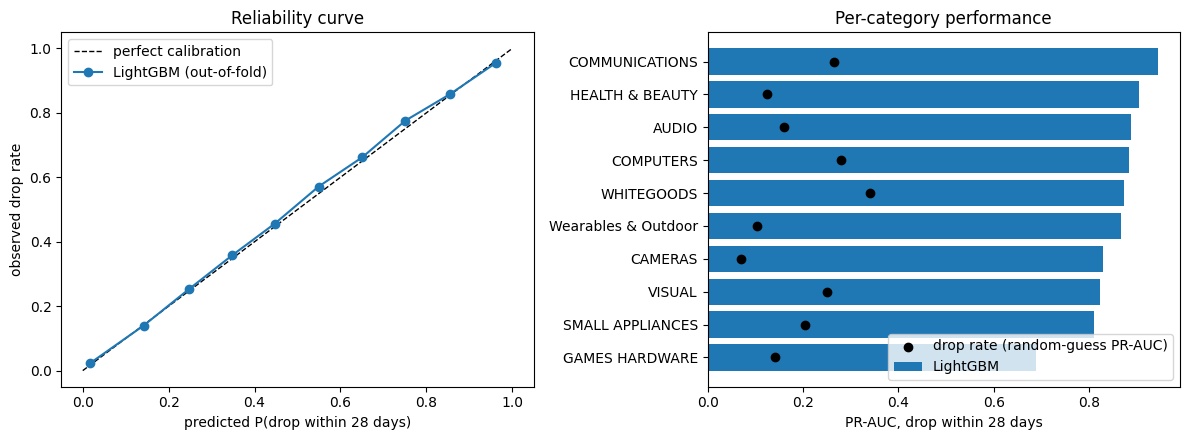

,product_type,n,drop_rate,pr_auc_model,pr_auc_base
4,GAMES HARDWARE,18945,0.141,0.688,0.135
6,SMALL APPLIANCES,33043,0.204,0.810,0.201
7,VISUAL,5534,0.250,0.822,0.245
1,CAMERAS,38512,0.070,0.830,0.068
9,Wearables & Outdoor,19066,0.103,0.867,0.100
8,WHITEGOODS,8825,0.342,0.873,0.327
3,COMPUTERS,12244,0.281,0.884,0.274
0,AUDIO,33072,0.161,0.888,0.159
5,HEALTH & BEAUTY,685,0.126,0.904,0.106
2,COMMUNICATIONS,4756,0.265,0.944,0.256


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
p_drop_model = 1 - oof["model"][:, NO_DROP]
edges = np.linspace(0, 1, 11)
idx = np.clip(np.digitize(p_drop_model, edges) - 1, 0, 9)
calib = pd.DataFrame({"bin": idx, "p": p_drop_model, "y": drop_bin}).groupby("bin").agg(p=("p", "mean"), y=("y", "mean"), n=("y", "size"))
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="perfect calibration")
axes[0].plot(calib.p, calib.y, "o-", label="LightGBM (out-of-fold)")
axes[0].set(xlabel="predicted P(drop within 28 days)", ylabel="observed drop rate", title="Reliability curve")
axes[0].legend()

per_type = []
for t_, rows in pd.Series(np.arange(len(samples))).groupby(samples.product_type).groups.items():
    rows = np.array(rows)
    if drop_bin[rows].sum() >= 20:
        per_type.append({"product_type": t_, "n": len(rows), "drop_rate": drop_bin[rows].mean(),
                         "pr_auc_model": average_precision_score(drop_bin[rows], p_drop_model[rows]),
                         "pr_auc_base": average_precision_score(drop_bin[rows], 1 - oof["base_type"][rows, NO_DROP])})
per_type = pd.DataFrame(per_type).sort_values("pr_auc_model")
axes[1].barh(per_type.product_type, per_type.pr_auc_model, label="LightGBM")
axes[1].scatter(per_type.drop_rate, per_type.product_type, color="k", zorder=3, label="drop rate (random-guess PR-AUC)")
axes[1].set(xlabel="PR-AUC, drop within 28 days", title="Per-category performance")
axes[1].legend(loc="lower right")
savefig("calibration_and_categories")
RESULTS["per_type"] = per_type.round(4).to_dict(orient="records")
per_type.round(3)

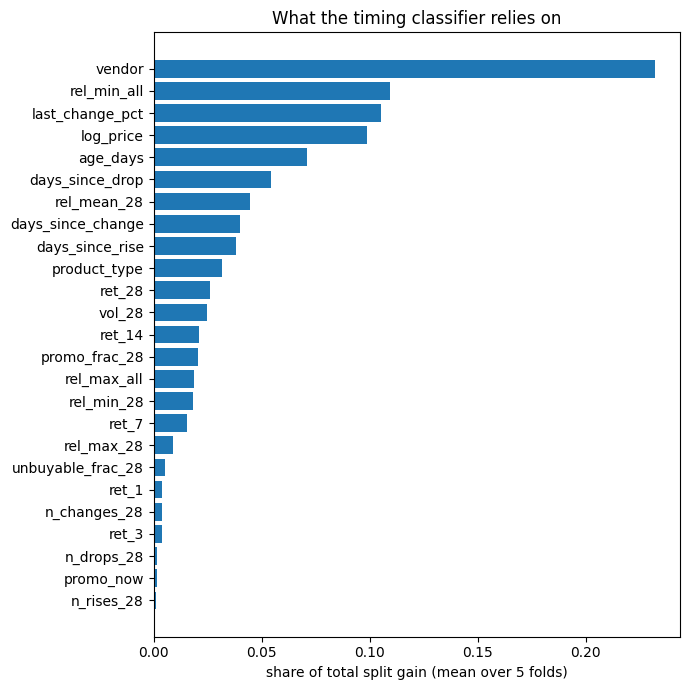

In [15]:
imp = pd.concat(importances, axis=1).mean(axis=1).sort_values()
imp = imp / imp.sum()
plt.figure(figsize=(7, 7))
plt.barh(imp.index, imp.values)
plt.xlabel("share of total split gain (mean over 5 folds)")
plt.title("What the timing classifier relies on")
savefig("feature_importance")
RESULTS["top_features"] = imp.sort_values(ascending=False).head(10).round(4).to_dict()

**Confusion between timing buckets** (argmax prediction, rows = true bucket, row-normalised).

In [16]:
pred_bucket = oof["model"].argmax(1)
cm = pd.crosstab(pd.Series(y, name="true"), pd.Series(pred_bucket, name="predicted"), normalize="index")
cm.index = [BUCKET_NAMES[i] for i in cm.index]
cm.columns = [BUCKET_NAMES[i] for i in cm.columns]
cm.round(3)

,1-7 days,8-14 days,15-28 days,no drop in 28 days
1-7 days,0.638,0.040,0.027,0.295
8-14 days,0.068,0.591,0.039,0.302
15-28 days,0.053,0.045,0.481,0.422
no drop in 28 days,0.007,0.005,0.006,0.981


## 8. Secondary check: does it work on a later time period?

Train on decision dates up to 15 July (their labels look ahead to 12 August), skip a 28-day gap, test on decision dates 12-31 August.
Only one such split fits in 5 months of data, so this is indicative. The test period is a quiet (non-sale) period.

The same split is used to compare **class weighting** (inverse square-root class frequency) against the unweighted model:
weighting boosts recall of rare drops but distorts probabilities.

It also checks a suspicion from section 7: `vendor` is the most important feature. In GroupKFold, other products of the same brand
*from the same weeks* are in the training folds, so brand-wide promotions can be "learned" from the test period itself.
If that is happening, the time split (which never trains on the test weeks) should score lower, and removing `vendor` should matter less there.

In [17]:
dates_arr = samples["date"].to_numpy()
tr_time = dates_arr <= np.datetime64("2026-07-15")
te_time = dates_arr >= np.datetime64("2026-08-12")
time_rows = []
clf_t, reg_t = fit_models(tr_time)
time_rows.append({"model": "LightGBM", **evaluate(clf_t.predict(X[te_time]), y[te_time])})
freq = np.bincount(y[tr_time], minlength=4) / tr_time.sum()
w = (1 / np.sqrt(freq))[y]
clf_w, _ = fit_lgb(CLF_PARAMS, X[tr_time], y[tr_time], groups[tr_time], w[tr_time]), None
time_rows.append({"model": "LightGBM + class weights", **evaluate(clf_w.predict(X[te_time]), y[te_time])})
no_vendor_params = {**CLF_PARAMS}
X_nv = X.drop(columns=["vendor"])
inner_tr, inner_va = next(GroupShuffleSplit(1, test_size=0.1, random_state=SEED).split(X_nv[tr_time], y[tr_time], groups[tr_time]))
d_tr = lgb.Dataset(X_nv[tr_time].iloc[inner_tr], y[tr_time][inner_tr], categorical_feature=["product_type"])
d_va = lgb.Dataset(X_nv[tr_time].iloc[inner_va], y[tr_time][inner_va], categorical_feature=["product_type"], reference=d_tr)
clf_nv = lgb.train(no_vendor_params, d_tr, 2000, valid_sets=[d_va], callbacks=[lgb.early_stopping(50, verbose=False)])
time_rows.append({"model": "LightGBM without vendor", **evaluate(clf_nv.predict(X_nv[te_time]), y[te_time])})
ba, bb = baseline_probs(tr_time, te_time)
time_rows.append({"model": "baseline: overall", **evaluate(ba, y[te_time])})
time_rows.append({"model": "baseline: per type", **evaluate(bb, y[te_time])})
time_df = pd.DataFrame(time_rows).set_index("model").round(4)
RESULTS["time_split"] = time_df.to_dict(orient="index")
print(f"train {tr_time.sum():,} samples, test {te_time.sum():,} samples")
time_df

train 80,173 samples, test 42,314 samples


,log_loss,brier,roc_auc,pr_auc,ece,drop_rate
model,,,,,,
LightGBM,0.6151,0.2560,0.8242,0.5079,0.0665,0.1561
LightGBM + class weights,0.6770,0.2749,0.8166,0.4970,0.0782,0.1561
LightGBM without vendor,0.6025,0.2581,0.7892,0.4665,0.0594,0.1561
baseline: overall,0.6037,0.2796,0.5000,0.1561,0.0040,0.1561
baseline: per type,0.5804,0.2719,0.6666,0.2429,0.0224,0.1561


## 9. Business metric: does following the model save money?

**Buy-or-wait simulation** on the out-of-fold predictions. A shopper wants the product on decision day *t*.

* **Buy now:** pay today's price.
* **Wait (rule):** watch for 28 days, buy at the first >= 5% drop; if none comes, buy on day 28 at whatever the price is then (it may be higher).
* **Model:** WAIT if $P(\text{drop within 28 days}) > \tau$, otherwise buy now.
* **Oracle:** knows the future, picks the cheaper of buy-now and wait.

The threshold $\tau$ is chosen to maximise savings on the *other* four folds and applied to the held-out fold (nested, no peeking).

This is where the loss and the real objective differ: cross-entropy treats a missed \$5 drop and a missed \$500 drop the same,
while the shopper only cares about dollars.

In [18]:
p0 = samples["price"].to_numpy()
wait_price = np.where(has_drop, samples["drop_price"].to_numpy(), samples["end_price"].to_numpy())
wait_days = np.where(has_drop, samples["drop_day"].to_numpy(), HORIZON)
save_wait = p0 - wait_price
save_oracle = np.maximum(save_wait, 0)
taus = np.round(np.arange(0.05, 0.96, 0.05), 2)


def policy_savings(p_drop, tau, sw=save_wait):
    wait = p_drop > tau
    return np.where(wait, sw, 0.0), wait


tau_by_fold = {}
save_model = np.zeros(len(samples))
wait_model = np.zeros(len(samples), bool)
for k in range(5):
    other, this = fold_id != k, fold_id == k
    best = max(taus, key=lambda t_: policy_savings(p_drop_model[other], t_, save_wait[other])[0].mean())
    tau_by_fold[k] = float(best)
    s, wmask = policy_savings(p_drop_model[this], best, save_wait[this])
    save_model[this], wait_model[this] = s, wmask

policies = {
    "buy now": (np.zeros(len(samples)), np.zeros(len(samples), bool)),
    "always wait": (save_wait, np.ones(len(samples), bool)),
    "model (tau tuned out-of-fold)": (save_model, wait_model),
    "oracle": (save_oracle, save_oracle > 0),
}
rows = []
for name, (s, wmask) in policies.items():
    rows.append({"policy": name, "mean_saving_$": s.mean(), "mean_saving_%": (s / p0).mean() * 100,
                 "share_of_oracle_%": s.sum() / save_oracle.sum() * 100, "wait_rate_%": wmask.mean() * 100,
                 "mean_days_waited": np.where(wmask, wait_days, 0).mean()})
savings_df = pd.DataFrame(rows).set_index("policy")
savings_df["saving_per_day_waited_$"] = savings_df["mean_saving_$"] / savings_df["mean_days_waited"].replace(0, np.nan)
savings_df = savings_df.round(2)
ci_save = bootstrap(lambda r: save_model[r].mean())
print("tau per fold:", tau_by_fold)
print("model mean saving 95% CI ($):", ci_save.round(2))
RESULTS["savings"] = savings_df.to_dict(orient="index")
RESULTS["savings_ci"] = ci_save.round(2).tolist()
RESULTS["tau_by_fold"] = tau_by_fold
savings_df

tau per fold: {0: 0.15, 1: 0.15, 2: 0.15, 3: 0.15, 4: 0.2}
model mean saving 95% CI ($): [22.13 24.77]


,mean_saving_$,mean_saving_%,share_of_oracle_%,wait_rate_%,mean_days_waited,saving_per_day_waited_$
policy,,,,,,
buy now,0.00,0.00,0.00,0.00,0.00,NaN
always wait,8.53,-0.29,31.26,100.00,25.40,0.34
model (tau tuned out-of-fold),23.37,2.60,85.64,22.50,4.01,5.82
oracle,27.29,3.19,100.00,17.47,2.29,11.92


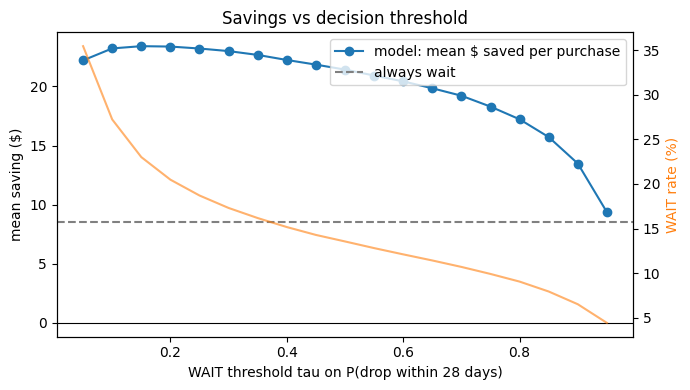

In [19]:
curve = [(t_, policy_savings(p_drop_model, t_)[0].mean(), policy_savings(p_drop_model, t_)[1].mean()) for t_ in taus]
curve = pd.DataFrame(curve, columns=["tau", "saving", "wait_rate"])
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(curve.tau, curve.saving, "o-", label="model: mean $ saved per purchase")
ax.axhline(save_wait.mean(), color="gray", ls="--", label="always wait")
ax.axhline(0, color="k", lw=0.8)
ax.set(xlabel="WAIT threshold tau on P(drop within 28 days)", ylabel="mean saving ($)", title="Savings vs decision threshold")
ax2 = ax.twinx(); ax2.plot(curve.tau, curve.wait_rate * 100, color="tab:orange", alpha=0.6); ax2.set_ylabel("WAIT rate (%)", color="tab:orange")
ax.legend(loc="upper right")
savefig("savings_vs_threshold")

**Where the loss and the objective disagree.** Among samples where the model said WAIT, the worst outcomes are those
where no drop came and the price went *up* by day 28; the costliest misses are big-ticket items where the model said BUY NOW
but a large drop followed.

In [20]:
err = samples.assign(p_drop=p_drop_model, saving_model=save_model, saving_oracle=save_oracle, wait=wait_model)
print("Costliest WAIT mistakes (price rose while waiting):")
display_cols = ["date", "title", "product_type", "price", "end_price", "p_drop", "saving_model"]
print(err[err.wait].nsmallest(5, "saving_model")[display_cols].to_string(index=False))
print("\nCostliest missed drops (said BUY NOW, big drop followed):")
missed = err[~err.wait].assign(missed=lambda d: d.saving_oracle)
print(missed.nlargest(5, "missed")[["date", "title", "product_type", "price", "drop_price", "p_drop", "missed"]].to_string(index=False))

Costliest WAIT mistakes (price rose while waiting):
      date                                                      title product_type   price  end_price   p_drop  saving_model
2026-06-15 Samsung 115" QN90F NEO QLED 4K Mini LED Smart AI TV [2025]       VISUAL 14921.0    26995.0 0.795110      -12074.0
2026-06-24 Samsung 115" QN90F NEO QLED 4K Mini LED Smart AI TV [2025]       VISUAL 14921.0    26995.0 0.696398      -12074.0
2026-06-29          Samsung 115" R95F Micro RGB 4K Smart AI TV [2026]       VISUAL 34888.0    41995.0 0.580634       -7107.0
2026-06-15           Samsung 85" R95H Micro RGB 4K Smart AI TV [2026]       VISUAL  7882.0     9995.0 0.843506       -2113.0
2026-08-31           Samsung 85" R95H Micro RGB 4K Smart AI TV [2026]       VISUAL  7992.0     9995.0 0.161561       -2003.0

Costliest missed drops (said BUY NOW, big drop followed):
      date                                                                                        title product_type   price  drop_price   

## 10. Top-10 flagships and the deployment interface

**Selection rule (reproducible).** For each of the 10 main categories: among products still listed and buyable on the JB website
(`jb_catalog_latest`) whose scrape coverage is within 10 points of the best-covered product in the category
(2026 TVs launched after scraping began, so an absolute threshold would exclude them), prefer products that The Good Guys also sells
(a popularity proxy: mainstream models are stocked by several retailers), then take the highest price (the category flagship).

The final model is refit on all labelled samples and exposed through `predict_drop(sku, as_of_date)`.

In [21]:
coverage = pd.Series((~np.isnan(P)).sum(0) / len(scrape_dates), index=skus, name="coverage")
listed = catalog[catalog.jb_listing_cta == "Buy"][["sku", "price"]].rename(columns={"price": "price_now"})
cand = (listed.merge(coverage, left_on="sku", right_index=True)
        .merge(products[["sku", "title", "product_type", "model_number"]], on="sku"))
main_types = products.product_type.value_counts().index[:10]
cand = cand[cand.product_type.isin(main_types)]
cand = cand[cand.coverage >= cand.groupby("product_type").coverage.transform("max") - 0.1].copy()
cand["at_tgg"] = cand.model_number.isin(tgg.model_number)
top10 = (cand.sort_values(["product_type", "at_tgg", "price_now"], ascending=[True, False, False])
         .groupby("product_type").head(1).reset_index(drop=True))
top10[["product_type", "sku", "title", "price_now", "coverage", "at_tgg"]]

,product_type,sku,title,price_now,coverage,at_tgg
0,AUDIO,841215,JBL BAR 1300 MK2 11.1.4ch True Atmos Soundbar ...,1999.00,0.983871,True
1,CAMERAS,881620,Antigravity A1 8K 360 Drone Explorer Bundle,2799.00,0.983871,True
2,COMMUNICATIONS,816142,Apple iPhone Air 1TB (Space Black),3099.00,0.983871,True
3,COMPUTERS,452763,"Apple MacBook Pro 16-inch with M5 Max Chip, 2T...",7999.00,0.967742,True
4,GAMES HARDWARE,749727,Xbox Series X 1TB Digital Console (Robot White),999.00,1.000000,True
5,HEALTH & BEAUTY,802752,NutriBullet NBY07200 Baby Steam & Blend,179.00,0.983871,True
6,SMALL APPLIANCES,894682,Jura Z10 Fully Automatic Coffee Machine (Alumi...,4499.00,0.983871,True
7,VISUAL,892006,"LG 97"" OLED EVO AI G6 4K Smart TV [2026]",29995.00,0.709677,True
8,WHITEGOODS,626212,ASKO DC7784HP.W.AU Heat Pump Drying Cabinet,6999.00,0.983871,True
9,Wearables & Outdoor,10005762,Pioneer SPH-EVO107DAB Wireless AV Receiver 10....,1248.85,0.983871,False


In [22]:
all_mask = np.ones(len(samples), bool)
clf_final, reg_final = fit_models(all_mask)
TAU_FINAL = float(max(taus, key=lambda t_: policy_savings(p_drop_model, t_)[0].mean()))
RESULTS["tau_final"] = TAU_FINAL


def predict_drop(sku, as_of_date, tau=TAU_FINAL):
    """Deployment interface. Input: a JB SKU and a date. Output: timing distribution, expected drop, recommendation."""
    t = date_pos[pd.Timestamp(as_of_date)]
    j = sku_pos[sku]
    x = make_X(np.array([t]), np.array([j]))
    p = clf_final.predict(x)[0]
    depth_pct = float(np.clip(reg_final.predict(x)[0], 0, 90))
    price_now = float(price_ff.iat[t, j])
    p_drop = float(1 - p[NO_DROP])
    return {
        "sku": sku,
        "as_of": str(pd.Timestamp(as_of_date).date()),
        "price_now": round(price_now, 2),
        "p_bucket": dict(zip(BUCKET_NAMES, np.round(p, 3).tolist())),
        "p_drop_28d": round(p_drop, 3),
        "expected_drop_pct_if_drop": round(depth_pct, 1),
        "expected_price_if_drop": round(price_now * (1 - depth_pct / 100), 2),
        "recommendation": "WAIT" if p_drop > tau else "BUY NOW",
    }


last_day = dates[-1]
demo = pd.DataFrame([{**predict_drop(s, last_day), "title": t_} for s, t_ in zip(top10.sku, top10.title)])
RESULTS["top10_predictions"] = demo.drop(columns=["p_bucket"]).to_dict(orient="records")
demo[["title", "price_now", "p_drop_28d", "expected_drop_pct_if_drop", "expected_price_if_drop", "recommendation"]]

,title,price_now,p_drop_28d,expected_drop_pct_if_drop,expected_price_if_drop,recommendation
0,JBL BAR 1300 MK2 11.1.4ch True Atmos Soundbar ...,1999.00,0.015,10.0,1799.72,BUY NOW
1,Antigravity A1 8K 360 Drone Explorer Bundle,2799.00,0.122,16.3,2342.62,BUY NOW
2,Apple iPhone Air 1TB (Space Black),3099.00,0.016,19.2,2502.46,BUY NOW
3,"Apple MacBook Pro 16-inch with M5 Max Chip, 2T...",7999.00,0.000,17.0,6635.89,BUY NOW
4,Xbox Series X 1TB Digital Console (Robot White),999.00,0.016,19.9,800.06,BUY NOW
5,NutriBullet NBY07200 Baby Steam & Blend,179.00,0.987,19.6,144.00,WAIT
6,Jura Z10 Fully Automatic Coffee Machine (Alumi...,4499.00,0.005,7.4,4164.27,BUY NOW
7,"LG 97"" OLED EVO AI G6 4K Smart TV [2026]",29995.00,0.664,8.6,27414.41,WAIT
8,ASKO DC7784HP.W.AU Heat Pump Drying Cabinet,6999.00,0.004,7.2,6496.61,BUY NOW
9,Pioneer SPH-EVO107DAB Wireless AV Receiver 10....,1248.85,0.134,7.4,1156.21,BUY NOW


In [23]:
predict_drop(top10.sku.iloc[0], last_day)

{'sku': np.int64(841215),
 'as_of': '2026-09-28',
 'price_now': 1999.0,
 'p_bucket': {'1-7 days': 0.001,
  '8-14 days': 0.004,
  '15-28 days': 0.01,
  'no drop in 28 days': 0.985},
 'p_drop_28d': 0.015,
 'expected_drop_pct_if_drop': 10.0,
 'expected_price_if_drop': 1799.72,
 'recommendation': 'BUY NOW'}

**Price timelines of the Top 10** with the out-of-fold predicted P(drop within 28 days) at each weekly decision date
(the model had not seen these products when making these predictions) and the actual >= 5% drops (red triangles).

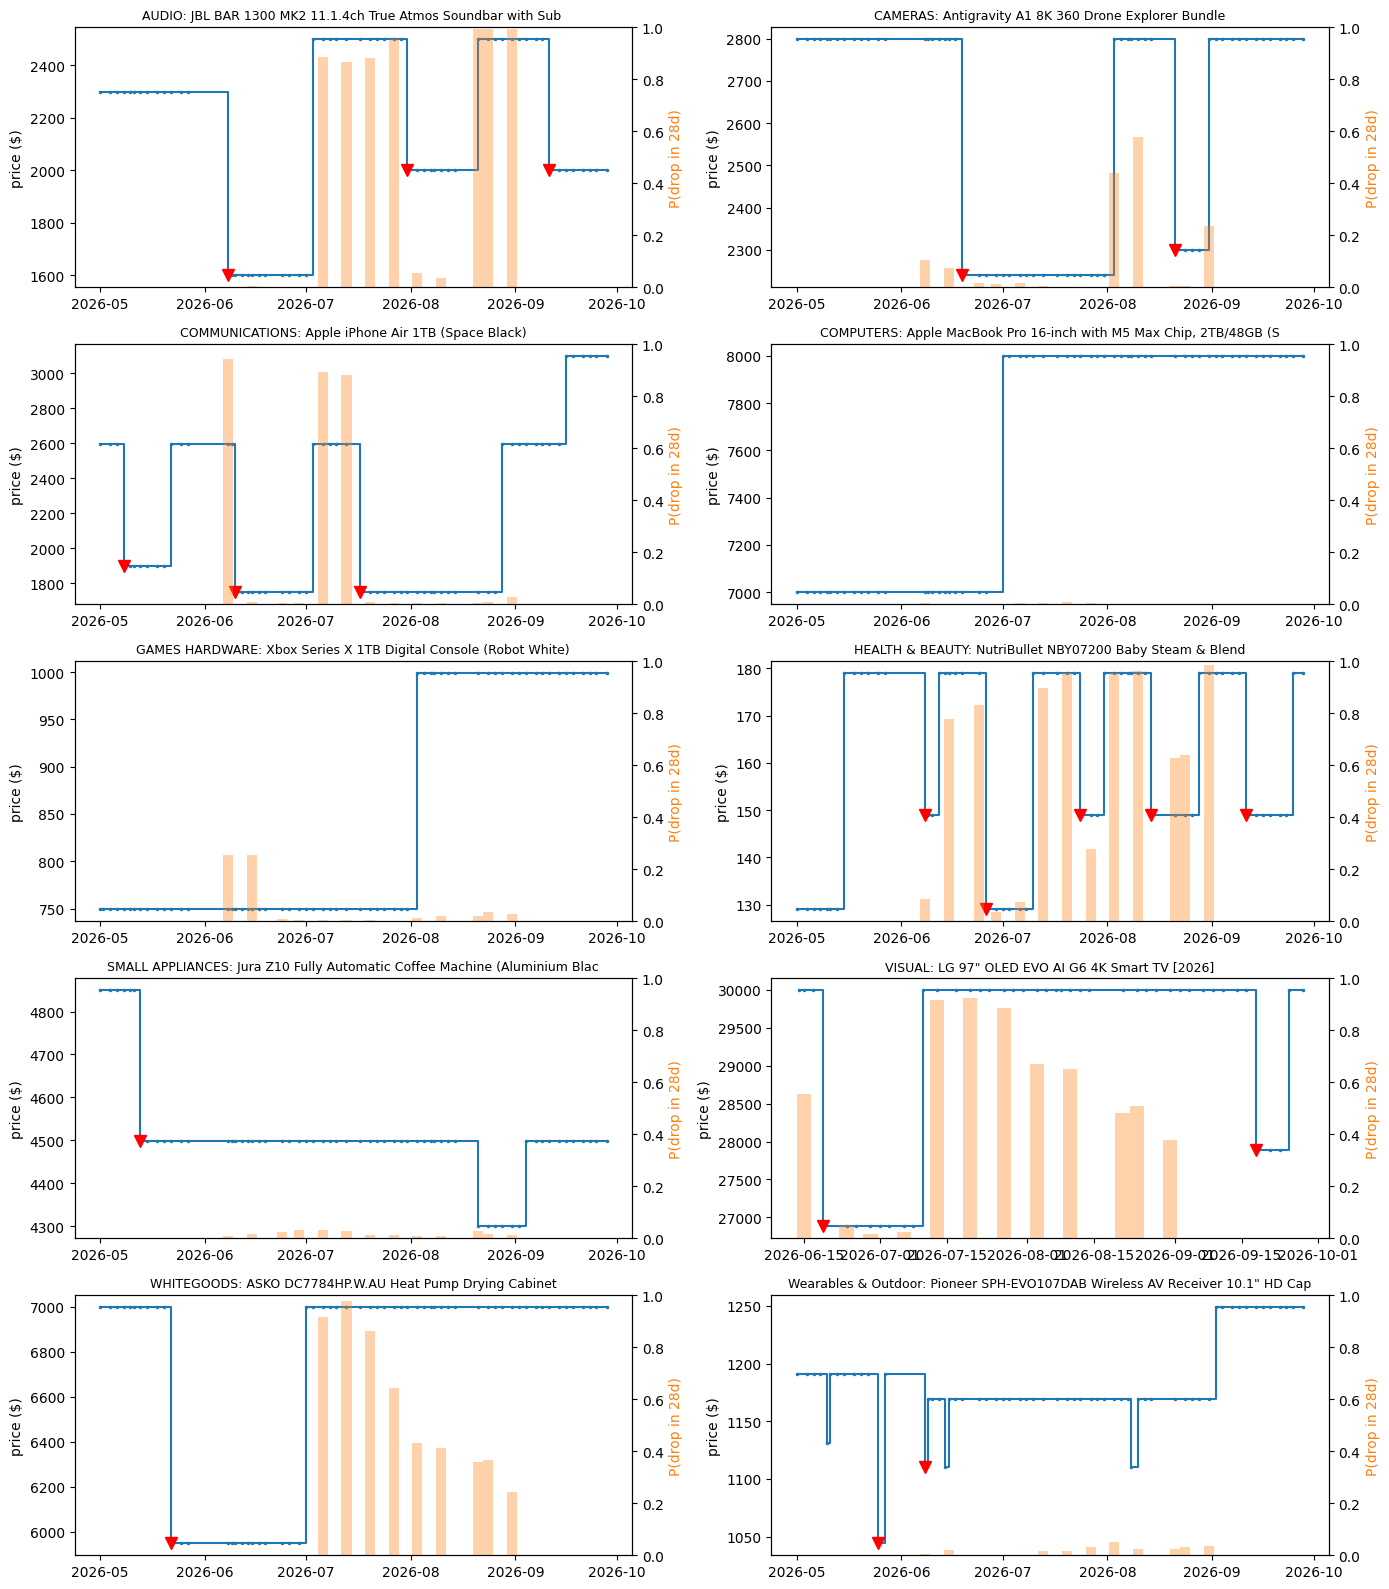

In [24]:
fig, axes = plt.subplots(5, 2, figsize=(14, 16))
for ax, (_, row) in zip(axes.ravel(), top10.iterrows()):
    j = sku_pos[row.sku]
    series = buy_price.iloc[:, j]
    ax.step(dates, series.ffill(), where="post", color="tab:blue")
    ax.plot(dates, series, ".", color="tab:blue", ms=3)
    drops = dates[np.nan_to_num(dropped[:, j], nan=0).astype(bool) & series.notna().to_numpy()]
    ax.plot(drops, series.ffill().reindex(drops), "v", color="red", ms=8)
    ax.set_title(f"{row.product_type}: {str(row.title)[:55]}", fontsize=9)
    ax.set_ylabel("price ($)")
    r = samples.index[samples.sku == row.sku]
    ax2 = ax.twinx()
    ax2.bar(samples.loc[r, "date"], p_drop_model[r], width=3, alpha=0.35, color="tab:orange")
    ax2.set_ylim(0, 1); ax2.set_ylabel("P(drop in 28d)", color="tab:orange")
for ax in axes.ravel()[len(top10):]:
    ax.axis("off")
savefig("top10_timelines")

## 11. Research question: do The Good Guys' prices help predict JB drops?

JB Hi-Fi advertises price matching, so a competitor undercutting JB might precede a JB drop.
The Good Guys prices are matched to JB SKUs by model number and carried forward for up to 7 days.
New features: `tgg_gap` (JB price / TGG price - 1; positive = JB is dearer), `tgg_ret_7` (TGG price change over 7 days),
`tgg_cheaper` (TGG at least 2% cheaper). Both models are compared with GroupKFold **on the matched subset only**.

In [25]:
tgg_wide = (tgg.pivot_table(index="date", columns="model_number", values="tgg_price", aggfunc="min")
            .reindex(dates).ffill(limit=7))
sku_model = products.set_index("sku").model_number.reindex(skus)
tgg_by_sku = tgg_wide.reindex(columns=sku_model.to_numpy()).to_numpy(dtype="float32")
tgg_7ago = np.vstack([np.full((7, N), np.nan, dtype="float32"), tgg_by_sku[:-7]])
jb_now = price_ff.to_numpy()
tgg_grids = {
    "tgg_gap": jb_now / tgg_by_sku - 1,
    "tgg_ret_7": tgg_by_sku / tgg_7ago - 1,
    "tgg_cheaper": (jb_now / tgg_by_sku - 1 > 0.02).astype("float32"),
}
t_idx, j_idx = samples.t.to_numpy(), samples.j.to_numpy()
X_tgg = X.copy()
for k_, g in tgg_grids.items():
    X_tgg[k_] = g[t_idx, j_idx]
matched = ~np.isnan(X_tgg["tgg_gap"].to_numpy())
print(f"matched samples: {matched.sum():,} ({matched.mean():.1%}), SKUs: {samples.sku[matched].nunique():,}")


def cv_on_subset(Xs, feats):
    ys, gs = y[matched], groups[matched]
    Xs = Xs.loc[matched, feats].reset_index(drop=True)
    probs = np.zeros((len(ys), 4))
    for tr, te in GroupKFold(5).split(Xs, ys, gs):
        inner_tr, inner_va = next(GroupShuffleSplit(1, test_size=0.1, random_state=SEED).split(Xs.iloc[tr], ys[tr], gs[tr]))
        dtr = lgb.Dataset(Xs.iloc[tr].iloc[inner_tr], ys[tr][inner_tr], categorical_feature=CAT_FEATURES)
        dva = lgb.Dataset(Xs.iloc[tr].iloc[inner_va], ys[tr][inner_va], categorical_feature=CAT_FEATURES, reference=dtr)
        m = lgb.train(CLF_PARAMS, dtr, 2000, valid_sets=[dva], callbacks=[lgb.early_stopping(50, verbose=False)])
        probs[te] = m.predict(Xs.iloc[te])
    return probs


probs_base = cv_on_subset(X_tgg, FEATURES)
probs_comp = cv_on_subset(X_tgg, FEATURES + list(tgg_grids))
ab = pd.DataFrame({"JB features only": evaluate(probs_base, y[matched]),
                   "JB + The Good Guys features": evaluate(probs_comp, y[matched])}).T
sw = save_wait[matched]
for name, pr in [("JB features only", probs_base), ("JB + The Good Guys features", probs_comp)]:
    pdp = 1 - pr[:, NO_DROP]
    ab.loc[name, "best_mean_saving_$"] = max(np.where(pdp > t_, sw, 0).mean() for t_ in taus)
RESULTS["competitor_ablation"] = ab.round(4).to_dict(orient="index")
ab.round(4)

matched samples: 22,373 (12.8%), SKUs: 2,095


,log_loss,brier,roc_auc,pr_auc,ece,drop_rate,best_mean_saving_$
JB features only,0.5309,0.2655,0.9374,0.9020,0.0132,0.3594,67.090599
JB + The Good Guys features,0.5230,0.2616,0.9390,0.9046,0.0115,0.3594,67.361198


## 12. Summary of results

All numbers above are regenerated when the notebook runs; the dictionary below collects them for the report.

In [26]:
results_path = FIG_DIR.parent / "results.json"
with open(results_path, "w") as f:
    json.dump(RESULTS, f, indent=2, default=str)
print(json.dumps({k: RESULTS[k] for k in ["n_samples", "n_skus", "skill", "depth_mae", "savings", "tau_final"]}, indent=2, default=str))

{
  "n_samples": 175038,
  "n_skus": 15322,
  "skill": {
    "base_overall": {
      "log_loss_skill": 0.5579428123979163,
      "brier_skill": 0.5439699245927552
    },
    "base_type": {
      "log_loss_skill": 0.5412815045104191,
      "brier_skill": 0.5312667056737157
    }
  },
  "depth_mae": {
    "model_pp": 3.7554274005223682,
    "baseline_pp": 7.880843018358692,
    "model_dollars": 32.27361729016863,
    "baseline_dollars": 63.0408457509688
  },
  "savings": {
    "buy now": {
      "mean_saving_$": 0.0,
      "mean_saving_%": 0.0,
      "share_of_oracle_%": 0.0,
      "wait_rate_%": 0.0,
      "mean_days_waited": 0.0,
      "saving_per_day_waited_$": NaN
    },
    "always wait": {
      "mean_saving_$": 8.53,
      "mean_saving_%": -0.29,
      "share_of_oracle_%": 31.26,
      "wait_rate_%": 100.0,
      "mean_days_waited": 25.399999618530273,
      "saving_per_day_waited_$": 0.34
    },
    "model (tau tuned out-of-fold)": {
      "mean_saving_$": 23.37,
      "mean_savi